In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import cv2

Manual Preprocessing

In [2]:
def load_and_preprocess_image(path, target_size=(224, 224)):
    """Clean preprocessing for wildfire images using letterbox resize only."""
    img = Image.open(path).convert("RGB")
    img = np.array(img)

    h, w = img.shape[:2]

    # Letterbox scaling (NO distortion)
    scale = min(target_size[0] / h, target_size[1] / w)
    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv2.resize(img, (new_w, new_h))

    # Create padded canvas
    canvas = np.zeros((target_size[0], target_size[1], 3), dtype=np.uint8)

    # Center image
    top = (target_size[0] - new_h) // 2
    left = (target_size[1] - new_w) // 2
    canvas[top:top + new_h, left:left + new_w] = resized

    # Normalize
    canvas = canvas.astype("float32") / 255.0




    return canvas


def is_safe_image(path, max_pixels=6000):
    """Skip large images that trigger decompression bomb warnings."""
    try:
        with Image.open(path) as img:
            w, h = img.size
            if w > max_pixels or h > max_pixels:
                return False
            return True
    except:
        return False


STEP 2: Load Dataset


In [3]:


data_dir = "/Users/akshon/Desktop/corrected_wildfires_dataset"

classes = [c for c in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, c))]
images = []
labels = []

for class_name in classes:
    class_folder = os.path.join(data_dir, class_name)
    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)

        # Skip non-image files
        if not img_name.lower().endswith(("jpg", "jpeg", "png", "tif", "tiff")):
            continue

        # Skip dangerous oversized images
        if not is_safe_image(img_path):
            print("⚠️ Skipping oversized image:", img_path)
            continue

        try:
            img = load_and_preprocess_image(img_path)
            images.append(img)
            labels.append(class_name)
        except Exception as e:
            print("❌ Error loading:", img_path, "|", e)
            continue

X = np.array(images)
y = np.array(labels)

print("Images loaded:", X.shape)
print("Labels loaded:", y.shape)

⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/fire/35751271762_db47281eee_o.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/fire/matt-palmer-Ihsi88KpQkE-unsplash.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/fire/43615020704_0b05413897_o.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/fire/matt-palmer-AuEVJLpb96k-unsplash.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/fire/44629829372_5916777e44_o.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/fire/42210817340_16e219716e_o.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/fire/30146885628_91cb57f5e9_o.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/fire/matt-palmer-qmFU0516eAk-unsplash.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_d

/Users/akshon/projectforestfire/.venv/lib/python3.11/site-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/nofire/35581707273_fed23248e8_o.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/nofire/dawson-mccormick-JM7go_siWXM-unsplash.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/nofire/cristofer-maximilian-ZmbOdU16tjY-unsplash.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/nofire/elena-mozhvilo-QHovAHM7jEw-unsplash.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/nofire/34663755142_cc51151b0a_o.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/nofire/hans-isaacson-U99MuqdVTx4-unsplash.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/nofire/dave-herring-Yqtv25PKjZo-unsplash.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/nofire/43048398825_ae99361954_o.jpg
⚠️ Skipping oversize

/Users/akshon/projectforestfire/.venv/lib/python3.11/site-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/nofire/35554264024_b33afa21ac_o.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/nofire/joshua-mauricio-End15pPXD5g-unsplash.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/nofire/francesco-ungaro-m1DjXxqwgMY-unsplash.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/nofire/dave-herring-xrjBELh1ybY-unsplash.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/nofire/dave-herring-NPpV-SRqpAw-unsplash.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/nofire/gerhard-crous-QcMsc21AzE4-unsplash.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/nofire/daniel-mirlea-qCMpxBhvURc-unsplash.jpg
⚠️ Skipping oversized image: /Users/akshon/Desktop/corrected_wildfires_dataset/nofire/christian-regg-o7LDdRDIYiY-unsplash.jpg
Images

STEP 3: Encode Labels

In [4]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

 STEP 4: Train-Val Split

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

STEP 5: Manual Augmentation Layer

In [6]:
import warnings
warnings.filterwarnings("ignore")
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

BATCH_SIZE = 16

2025-11-29 15:03:23.844297: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-11-29 15:03:23.844933: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-11-29 15:03:23.844942: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-11-29 15:03:23.846133: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-29 15:03:23.846877: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


STEP 6: Build CNN (MobileNetV2)

In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_tensor=Input(shape=(224, 224, 3))
)

# Freeze most layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(64, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
predictions = Dense(2, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[0][0]']        

STEP 7: Train Model

In [8]:
import warnings
warnings.filterwarnings("ignore")
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau)

early_stop = EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)

history = model.fit(
    data_augmentation(X_train),
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=2
)

2025-11-29 15:03:26.861250: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-11-29 15:03:30.095333: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


Epoch 1/15


2025-11-29 15:03:33.997827: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2025-11-29 15:03:34.275245: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


52/52 - 16s - loss: 0.6143 - accuracy: 0.7037 - val_loss: 0.3249 - val_accuracy: 0.8634 - lr: 1.0000e-04 - 16s/epoch - 314ms/step
Epoch 2/15
52/52 - 11s - loss: 0.3005 - accuracy: 0.8671 - val_loss: 0.2817 - val_accuracy: 0.8732 - lr: 1.0000e-04 - 11s/epoch - 204ms/step
Epoch 3/15
52/52 - 9s - loss: 0.2140 - accuracy: 0.9134 - val_loss: 0.2448 - val_accuracy: 0.9171 - lr: 1.0000e-04 - 9s/epoch - 179ms/step
Epoch 4/15
52/52 - 9s - loss: 0.1771 - accuracy: 0.9293 - val_loss: 0.2479 - val_accuracy: 0.9122 - lr: 1.0000e-04 - 9s/epoch - 166ms/step
Epoch 5/15
52/52 - 9s - loss: 0.1236 - accuracy: 0.9610 - val_loss: 0.2495 - val_accuracy: 0.9122 - lr: 1.0000e-04 - 9s/epoch - 172ms/step
Epoch 6/15
52/52 - 8s - loss: 0.1301 - accuracy: 0.9500 - val_loss: 0.2646 - val_accuracy: 0.8976 - lr: 1.0000e-04 - 8s/epoch - 161ms/step
Epoch 7/15
52/52 - 8s - loss: 0.0995 - accuracy: 0.9659 - val_loss: 0.2350 - val_accuracy: 0.9220 - lr: 5.0000e-05 - 8s/epoch - 162ms/step
Epoch 8/15
52/52 - 8s - loss: 0.10

STEP 8: Evaluate Model

13/13 [==============================] - 2s 131ms/step - loss: 0.2473 - accuracy: 0.9171
Test Accuracy: 0.9171
7/7 [==============================] - 2s 193ms/step


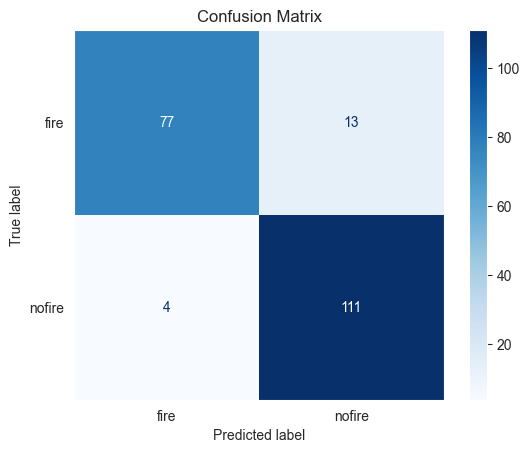

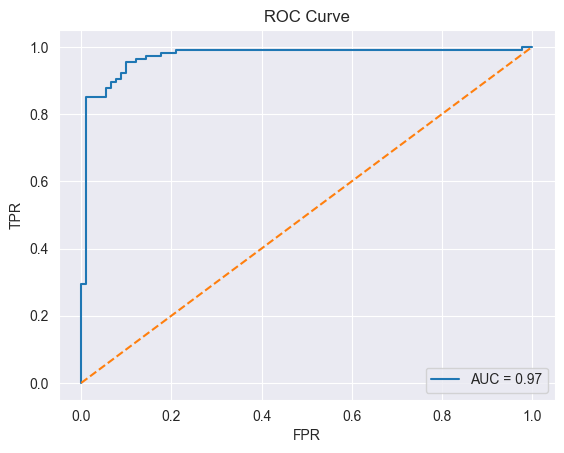


Classification Report:

              precision    recall  f1-score   support

        fire       0.95      0.86      0.90        90
      nofire       0.90      0.97      0.93       115

    accuracy                           0.92       205
   macro avg       0.92      0.91      0.91       205
weighted avg       0.92      0.92      0.92       205

Cohen's Kappa Score: 0.8298


In [9]:
loss, accuracy = model.evaluate(X_val, y_val, batch_size=BATCH_SIZE)
print(f"Test Accuracy: {accuracy:.4f}")

# -----------------------
# STEP 9: Save Model
# -----------------------

model.save("ffcl_model_manual.h5")


# -----------------------
# STEP 10: Metrics & Graphs
# -----------------------

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc, cohen_kappa_score
from sklearn.preprocessing import label_binarize
import seaborn as sns

y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

# ROC Curve
y_true_bin = label_binarize(y_true, classes=[0, 1])
fpr, tpr, _ = roc_curve(y_true_bin, y_pred_probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Kappa Score
kappa = cohen_kappa_score(y_true, y_pred)
print(f"Cohen's Kappa Score: {kappa:.4f}")

🚀 Running ResNet50 pipeline...


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_3[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                        

2025-11-29 13:51:24.204338: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-11-29 13:51:27.765016: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


Epoch 1/15


2025-11-29 13:51:33.090532: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2025-11-29 13:51:33.346260: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


410/410 - 38s - loss: 0.9348 - accuracy: 0.5305 - val_loss: 1.5891 - val_accuracy: 0.5317 - lr: 1.0000e-04 - 38s/epoch - 93ms/step
Epoch 2/15
410/410 - 31s - loss: 0.9556 - accuracy: 0.5500 - val_loss: 1.2756 - val_accuracy: 0.4195 - lr: 1.0000e-04 - 31s/epoch - 76ms/step
Epoch 3/15
410/410 - 37s - loss: 0.8884 - accuracy: 0.5195 - val_loss: 1.2054 - val_accuracy: 0.5512 - lr: 1.0000e-04 - 37s/epoch - 90ms/step
Epoch 4/15
410/410 - 29s - loss: 0.8743 - accuracy: 0.5073 - val_loss: 1.3572 - val_accuracy: 0.5220 - lr: 1.0000e-04 - 29s/epoch - 70ms/step
Epoch 5/15
410/410 - 28s - loss: 0.8002 - accuracy: 0.5073 - val_loss: 0.9465 - val_accuracy: 0.5024 - lr: 1.0000e-04 - 28s/epoch - 69ms/step
Epoch 6/15
410/410 - 28s - loss: 0.7884 - accuracy: 0.5280 - val_loss: 1.4156 - val_accuracy: 0.4146 - lr: 1.0000e-04 - 28s/epoch - 69ms/step
Epoch 7/15
410/410 - 29s - loss: 0.7243 - accuracy: 0.5488 - val_loss: 0.9761 - val_accuracy: 0.5561 - lr: 1.0000e-04 - 29s/epoch - 70ms/step
Epoch 8/15
410/41

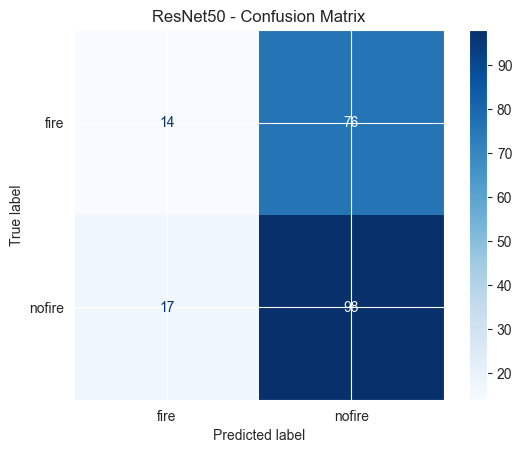

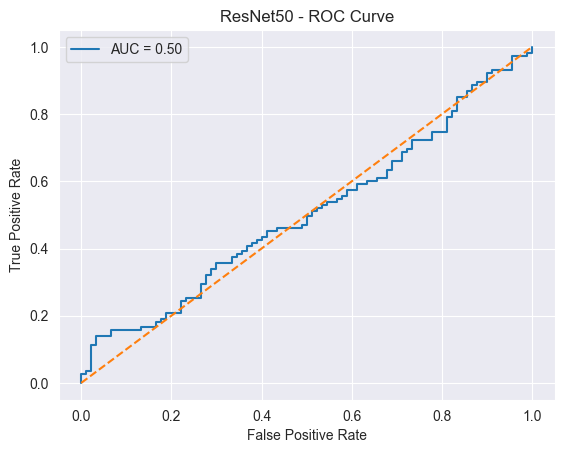


Classification Report:
              precision    recall  f1-score   support

        fire       0.45      0.16      0.23        90
      nofire       0.56      0.85      0.68       115

    accuracy                           0.55       205
   macro avg       0.51      0.50      0.45       205
weighted avg       0.51      0.55      0.48       205


Cohen's Kappa Score: 0.0083

✅ ResNet50 pipeline complete!


In [12]:
# ================================================
# DRIVER CELL (ResNet50 Full Training + Eval)
# ================================================

print("🚀 Running ResNet50 pipeline...")

# ---------------------------
# 1) ResNet50 MODEL
# ---------------------------
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_tensor=Input(shape=(224, 224, 3))
)

# Freeze majority layers
for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Classification Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(64, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

predictions = Dense(2, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# ---------------------------
# 2) Train ResNet50
# ---------------------------
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3
)

print("\n🔥 Training ResNet50...\n")

history = model.fit(
    data_augmentation(X_train),
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=2,
    callbacks=[early_stop, reduce_lr],
    verbose=2
)

# ---------------------------
# 3) Evaluate Model
# ---------------------------
print("\n📊 Evaluating...")
loss, accuracy = model.evaluate(X_val, y_val, batch_size=4)
print(f"\n🔥 ResNet50 Accuracy: {accuracy:.4f}")

# ---------------------------
# 4) Predictions
# ---------------------------
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)

print("Graphs below...")


# ---------------------------
# 5) Confusion Matrix
# ---------------------------
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("ResNet50 - Confusion Matrix")
plt.show()


# ---------------------------
# 6) ROC Curve
# ---------------------------
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true_bin = label_binarize(y_true, classes=[0, 1])
fpr, tpr, _ = roc_curve(y_true_bin, y_pred_probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ResNet50 - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


# ---------------------------
# 7) Classification Report
# ---------------------------
from sklearn.metrics import classification_report, cohen_kappa_score

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))

kappa = cohen_kappa_score(y_true, y_pred)
print(f"\nCohen's Kappa Score: {kappa:.4f}")

print("\n✅ ResNet50 pipeline complete!")

In [1]:
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image
import cv2

# -------------------------
# SAME PREPROCESSING USED DURING TRAINING
# -------------------------
def load_and_preprocess_image(path, target_size=(224, 224)):
    img = Image.open(path).convert("RGB")
    img = np.array(img)

    h, w = img.shape[:2]

    # Letterbox scaling
    scale = min(target_size[0] / h, target_size[1] / w)
    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv2.resize(img, (new_w, new_h))

    # Create padded canvas
    canvas = np.zeros((target_size[0], target_size[1], 3), dtype=np.uint8)

    # Centering
    top = (target_size[0] - new_h) // 2
    left = (target_size[1] - new_w) // 2
    canvas[top:top + new_h, left:left + new_w] = resized

    # Normalize
    canvas = canvas.astype("float32") / 255.0

    return canvas

# -------------------------
# LOAD YOUR TRAINED MODEL
# -------------------------
model = load_model("ffcl_model_manual.h5")

# -------------------------
# MAKE PREDICTION FUNCTION
# -------------------------
def predict_image(image_path):
    img = load_and_preprocess_image(image_path)
    img = np.expand_dims(img, axis=0)   # Add batch dimension

    preds = model.predict(img)
    label_idx = np.argmax(preds)

    print("\nPredicted Class Index:", label_idx)
    print("Raw Probabilities:", preds)

    # If your classes are ['Fire', 'Non-Fire']
    classes = ["Fire", "Non-Fire"]
    print("\n🔥 Final Prediction:", classes[label_idx])

    return classes[label_idx]

# -------------------------
# TEST YOUR IMAGE
# -------------------------
image_path = input("Enter image path: ")
predict_image(image_path)

2025-11-29 13:46:09.980208: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-11-29 13:46:09.980245: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-11-29 13:46:09.980250: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-11-29 13:46:09.980643: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-29 13:46:09.981010: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


KeyboardInterrupt: Interrupted by user